<a href="https://colab.research.google.com/github/sandydiamantino/retailrocket-topsis/blob/main/retailrocket_topsis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Benchmark de Recomendação com Grafo e TOPSIS

Este notebook apresenta um experimento inicial de recomendação de produtos
utilizando o dataset Retailrocket.

O objetivo é comparar:

1. Uma ordenação simples dos produtos candidatos.
2. Uma ordenação multicritério utilizando o método TOPSIS.

## Etapa 1: Análise Exploratória dos Dados

Nesta etapa será realizada a análise exploratória dos dados.

### Importando as bibliotecas

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

sns.set_theme(style='whitegrid')

print('Bibliotecas carregadas com sucesso.')

Bibliotecas carregadas com sucesso.


### Definindo os links Raw

In [30]:
EVENTS_URL = (
    'https://raw.githubusercontent.com/sandydiamantino/retailrocket-topsis/refs/heads/main/data/sample_events.csv'
)

PROPERTIES_URL = (
    'https://raw.githubusercontent.com/sandydiamantino/retailrocket-topsis/refs/heads/main/data/sample_item_properties.csv'
)

print('Links definidos.')

Links definidos.


### Testando os links Raw

In [31]:
import requests

urls = {
    'events': EVENTS_URL,
    'properties': PROPERTIES_URL
}

for name, url in urls.items():
    response = requests.get(url)

    print(f'{name}: status HTTP {response.status_code}')

    if response.status_code == 200:
        print('  Link acessível.')
    else:
        print('  Verifique o link, o nome do arquivo ou a visibilidade do repositório.')

events: status HTTP 200
  Link acessível.
properties: status HTTP 200
  Link acessível.


### Carregando os arquivos

In [32]:
events = pd.read_csv(EVENTS_URL)

properties = pd.read_csv(PROPERTIES_URL)

print('Arquivos carregados com sucesso.')

Arquivos carregados com sucesso.


### Verificando o tamanho das tabelas

In [33]:
print('Tabela de eventos:')
print(f'Linhas: {events.shape[0]:,}')
print(f'Colunas: {events.shape[1]}')

print('\nTabela de propriedades:')
print(f'Linhas: {properties.shape[0]:,}')
print(f'Colunas: {properties.shape[1]}')

Tabela de eventos:
Linhas: 9,385
Colunas: 6

Tabela de propriedades:
Linhas: 392,648
Colunas: 4


### Visualizando as primeiras linhas

In [34]:
# Os eventos
display(events.head())

,timestamp,visitorid,event,itemid,transactionid,datetime
0,1433193132535,1134473,view,396045,NaN,2015-06-01 21:12:12.535
1,1433194696771,1314862,view,344224,NaN,2015-06-01 21:38:16.771
2,1433220848630,467124,view,396318,NaN,2015-06-02 04:54:08.630
3,1433218109710,1121229,view,370889,NaN,2015-06-02 04:08:29.710
4,1433178802896,39027,view,26210,NaN,2015-06-01 17:13:22.896


In [35]:
# As propriedades
display(properties.head())

,timestamp,itemid,property,value
0,1431831600000,156781,917,828513
1,1433646000000,272201,790,n10320.000
2,1440298800000,368230,400,1297729 n720.000 1178208 n900.000 424566
3,1431831600000,329408,888,1333963 747375 927741 1071593 547687 199524
4,1431831600000,103584,790,n459360.000


### Verificando os nomes das colunas

In [36]:
print('Colunas da tabela de eventos:')
print(events.columns.tolist())

print('\nColunas da tabela de propriedades:')
print(properties.columns.tolist())

Colunas da tabela de eventos:
['timestamp', 'visitorid', 'event', 'itemid', 'transactionid', 'datetime']

Colunas da tabela de propriedades:
['timestamp', 'itemid', 'property', 'value']


### Verificando os tipos das colunas

In [37]:
print('Tipos das colunas de eventos:')
display(events.dtypes.to_frame('tipo'))

print('Tipos das colunas de propriedades:')
display(properties.dtypes.to_frame('tipo'))

Tipos das colunas de eventos:


,tipo
timestamp,int64
visitorid,int64
event,object
itemid,int64
transactionid,float64
datetime,object


Tipos das colunas de propriedades:


,tipo
timestamp,int64
itemid,int64
property,object
value,object


### Garantindo a coluna de data

In [38]:
if 'datetime' not in events.columns:
    events['datetime'] = pd.to_datetime(
        events['timestamp'],
        unit='ms'
    )
else:
    events['datetime'] = pd.to_datetime(
        events['datetime'],
        errors='coerce'
    )

print(events['datetime'].dtype)
display(events[['timestamp', 'datetime']].head())

datetime64[ns]


,timestamp,datetime
0,1433193132535,2015-06-01 21:12:12.535
1,1433194696771,2015-06-01 21:38:16.771
2,1433220848630,2015-06-02 04:54:08.630
3,1433218109710,2015-06-02 04:08:29.710
4,1433178802896,2015-06-01 17:13:22.896


### Verificando valores ausentes

In [39]:
# Para eventos
missing_events = (
    events.isna()
    .sum()
    .sort_values(ascending=False)
    .to_frame('quantidade')
)

display(missing_events)

,quantidade
transactionid,9339
timestamp,0
visitorid,0
event,0
itemid,0
datetime,0


In [40]:
# Para propriedades
missing_properties = (
    properties.isna()
    .sum()
    .sort_values(ascending=False)
    .to_frame('quantidade')
)

display(missing_properties)

,quantidade
timestamp,0
itemid,0
property,0
value,0


### Contando os tipos e calculando o percentual de cada evento

In [41]:
# Contando os tipos de eventos
event_counts = (
    events['event']
    .value_counts()
    .rename_axis('tipo_evento')
    .reset_index(name='quantidade')
)

display(event_counts)

# Calculando o percentual de cada evento
event_percentages = (
    events['event']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .rename_axis('tipo_evento')
    .reset_index(name='percentual')
)

display(event_percentages)

,tipo_evento,quantidade
0,view,9076
1,addtocart,263
2,transaction,46


,tipo_evento,percentual
0,view,96.71
1,addtocart,2.80
2,transaction,0.49


### Gráficos: Eventos

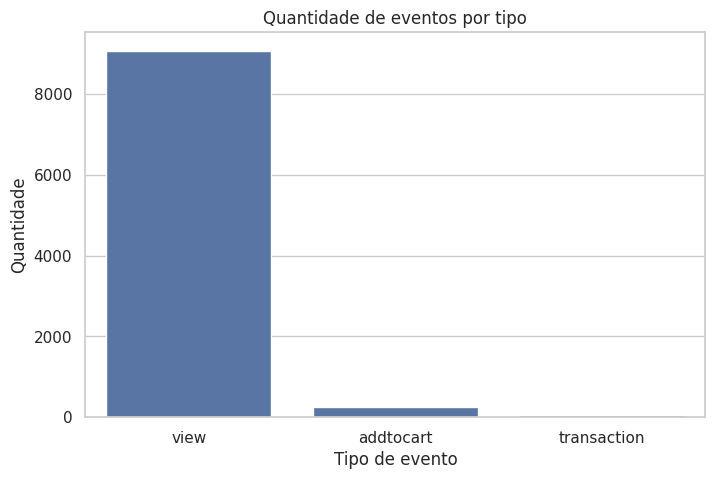

In [42]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=events,
    x='event',
    order=events['event'].value_counts().index
)

plt.title('Quantidade de eventos por tipo')
plt.xlabel('Tipo de evento')
plt.ylabel('Quantidade')

plt.show()

### Visitantes / Produto

In [43]:
summary = pd.DataFrame({
    'indicador': [
        'Eventos',
        'Visitantes únicos',
        'Produtos únicos',
        'Transações identificadas'
    ],
    'quantidade': [
        len(events),
        events['visitorid'].nunique(),
        events['itemid'].nunique(),
        events['transactionid'].notna().sum()
    ]
})

display(summary)

,indicador,quantidade
0,Eventos,9385
1,Visitantes únicos,5000
2,Produtos únicos,6610
3,Transações identificadas,46


### Visitantes / Tipo de Evento

In [44]:
visitors_by_event = (
    events.groupby('event')['visitorid']
    .nunique()
    .sort_values(ascending=False)
    .rename('visitantes_unicos')
    .to_frame()
)

display(visitors_by_event)

,visitantes_unicos
event,
view,4991
addtocart,145
transaction,39


### Produtos / Tipo de Interação

In [45]:
products_by_event = (
    events.groupby('event')['itemid']
    .nunique()
    .sort_values(ascending=False)
    .rename('produtos_unicos')
    .to_frame()
)

display(products_by_event)

,produtos_unicos
event,
view,6564
addtocart,225
transaction,46


### Período dos dados

In [46]:
print('Primeiro evento:')
print(events['datetime'].min())

print('\nÚltimo evento:')
print(events['datetime'].max())

Primeiro evento:
2015-05-03 03:02:00.563000

Último evento:
2015-09-18 01:16:53.281000


In [47]:
# Quanto eventos ocorreram por dia
events_by_day = (
    events
    .set_index('datetime')
    .resample('D')
    .size()
    .rename('quantidade_eventos')
)

display(events_by_day.head())

,quantidade_eventos
datetime,
2015-05-03,24
2015-05-04,60
2015-05-05,67
2015-05-06,87
2015-05-07,123


### Gráfico: Eventos ao longo do tempo

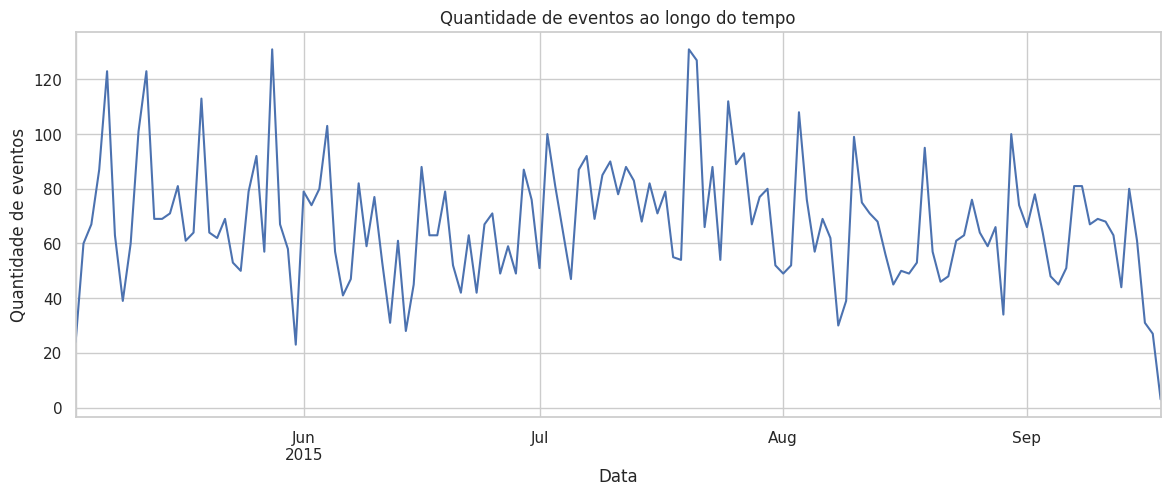

In [48]:
plt.figure(figsize=(14, 5))

events_by_day.plot()

plt.title('Quantidade de eventos ao longo do tempo')
plt.xlabel('Data')
plt.ylabel('Quantidade de eventos')

plt.show()

### Separando as transações

In [49]:
transactions = events[
    events['event'] == 'transaction'
].copy()

print('Eventos de compra:', len(transactions))
print('Visitantes que compraram:', transactions['visitorid'].nunique())
print('Produtos comprados:', transactions['itemid'].nunique())

display(transactions.head())

Eventos de compra: 46
Visitantes que compraram: 39
Produtos comprados: 46


,timestamp,visitorid,event,itemid,transactionid,datetime
241,1433440854985,1207981,transaction,350734,8693.0,2015-06-04 18:00:54.985
324,1433446155080,763580,transaction,257115,15026.0,2015-06-04 19:29:15.080
484,1433748335994,766502,transaction,414995,10859.0,2015-06-08 07:25:35.994
488,1433787533953,293600,transaction,55044,3462.0,2015-06-08 18:18:53.953
612,1433976818104,343404,transaction,44220,16824.0,2015-06-10 22:53:38.104


### Produtos mais visualizados

In [50]:
most_viewed = (
    events[events['event'] == 'view']
    .groupby('itemid')
    .size()
    .sort_values(ascending=False)
    .head(10)
    .rename('visualizacoes')
    .to_frame()
)

display(most_viewed)

,visualizacoes
itemid,
153401,33
95489,30
447661,19
212583,18
322920,14
461686,12
187946,11
20407,11
234255,10


### Produtos mais comprados

,compras
itemid,
698,1
18171,1
20407,1
22145,1
36290,1
44220,1
50684,1
55044,1
76426,1


<Figure size 1200x500 with 0 Axes>

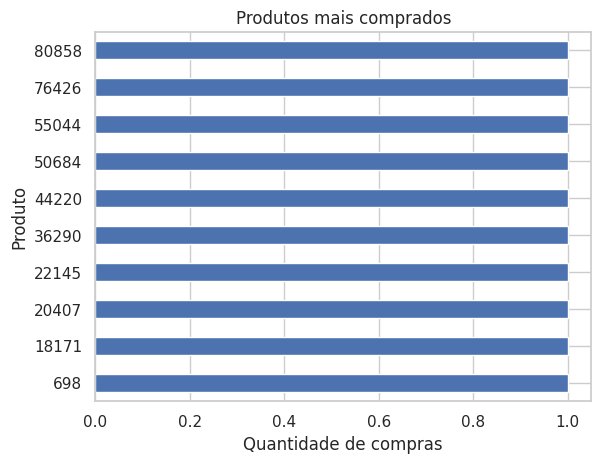

In [51]:
most_purchased = (
    transactions
    .groupby('itemid')
    .size()
    .sort_values(ascending=False)
    .head(10)
    .rename('compras')
    .to_frame()
)

display(most_purchased)

# Gráfico
plt.figure(figsize=(12, 5))

most_purchased.sort_values('compras').plot(
    kind='barh',
    legend=False
)

plt.title('Produtos mais comprados')
plt.xlabel('Quantidade de compras')
plt.ylabel('Produto')

plt.show()

### Eventos / Visitante

,quantidade_eventos
count,5000.000000
mean,1.877000
std,2.796826
min,1.000000
25%,1.000000
50%,1.000000
75%,2.000000
max,55.000000


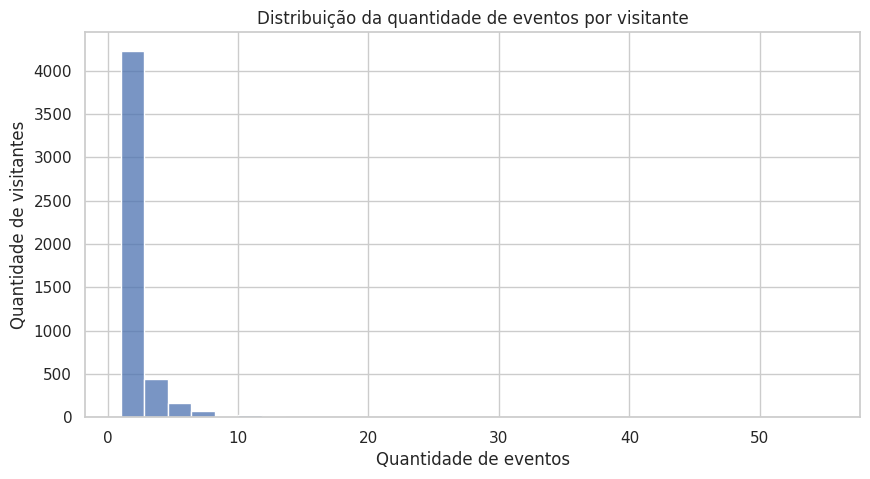

In [52]:
events_per_visitor = (
    events.groupby('visitorid')
    .size()
    .rename('quantidade_eventos')
)

display(events_per_visitor.describe())

plt.figure(figsize=(10, 5))

sns.histplot(
    events_per_visitor,
    bins=30,
    kde=False
)

plt.title('Distribuição da quantidade de eventos por visitante')
plt.xlabel('Quantidade de eventos')
plt.ylabel('Quantidade de visitantes')

plt.show()

### Taxa simples de conversão por produto

In [53]:
views_by_item = (
    events[events['event'] == 'view']
    .groupby('itemid')
    .size()
    .rename('visualizacoes')
)

transactions_by_item = (
    events[events['event'] == 'transaction']
    .groupby('itemid')
    .size()
    .rename('transacoes')
)

item_statistics = pd.concat(
    [views_by_item, transactions_by_item],
    axis=1
).fillna(0)

item_statistics['taxa_conversao'] = (
    item_statistics['transacoes'] /
    item_statistics['visualizacoes'].clip(lower=1)
)

item_statistics = item_statistics.sort_values(
    'taxa_conversao',
    ascending=False
)

display(item_statistics.head(10))

,visualizacoes,transacoes,taxa_conversao
itemid,,,
36290,1.0,1.0,1.0
85377,1.0,1.0,1.0
257115,1.0,1.0,1.0
108924,1.0,1.0,1.0
361982,1.0,1.0,1.0
415562,1.0,1.0,1.0
408504,1.0,1.0,1.0
365758,0.0,1.0,1.0
144599,0.0,1.0,1.0


### Salvando os resultados

In [54]:
event_counts.to_csv(
    '/content/event_counts.csv',
    index=False
)

summary.to_csv(
    '/content/dataset_summary.csv',
    index=False
)

item_statistics.to_csv(
    '/content/item_statistics.csv'
)

print('Tabelas exploratórias salvas em /content.')

Tabelas exploratórias salvas em /content.


## Etapa 2: Construindo o grafo de interações

Nesta etapa será construído um grafo bipartido entre visitantes e produtos.

Cada aresta representa uma interação de um visitante com um produto.
Os diferentes tipos de evento receberão pesos diferentes:
- visualização;
- adição ao carrinho;
- transação.

In [55]:
# Importando o NetworkX
import networkx as nx

print('NetworkX carregado com sucesso.')

# Preparando os eventos
interactions = events[
    ['visitorid', 'itemid', 'event', 'datetime']
].copy()

interactions.head()

# Verificando se existem valores ausentes
print('Valores ausentes:')
display(interactions.isna().sum().to_frame('quantidade'))

# Removendo linhas sem visitante ou sem produto
interactions = interactions.dropna(
    subset=['visitorid', 'itemid']
).copy()

print('Eventos após remoção de valores ausentes:', len(interactions))

NetworkX carregado com sucesso.
Valores ausentes:


,quantidade
visitorid,0
itemid,0
event,0
datetime,0


Eventos após remoção de valores ausentes: 9385


### Atribuindo pesos aos eventos

| Evento      | Peso |
| ----------- | ---- |
| view        | 1    |
| addtocart   | 3    |
| transaction | 5    |


In [56]:
event_weights = {
    'view': 1.0,
    'addtocart': 3.0,
    'transaction': 5.0
}

interactions['edge_weight'] = (
    interactions['event']
    .map(event_weights)
    .fillna(0)
)

display(
    interactions[
        ['visitorid', 'itemid', 'event', 'edge_weight']
    ].head(10)
)

# Verificando
interactions['edge_weight'].value_counts()

,visitorid,itemid,event,edge_weight
0,1134473,396045,view,1.0
1,1314862,344224,view,1.0
2,467124,396318,view,1.0
3,1121229,370889,view,1.0
4,39027,26210,view,1.0
5,39027,190172,view,1.0
6,1246312,104261,view,1.0
7,595804,162525,view,1.0
8,1342843,55124,view,1.0
9,1125119,105246,view,1.0


,count
edge_weight,
1.0,9076
3.0,263
5.0,46


### Agregando interações repetidas

In [57]:
edge_data = (
    interactions
    .groupby(['visitorid', 'itemid'], as_index=False)
    .agg(
        weight=('edge_weight', 'sum'),
        interaction_count=('event', 'size'),
        last_interaction=('datetime', 'max')
    )
)

edge_data.head()

# Verificando
print('Relações únicas visitante-produto:', len(edge_data))
print('Visitantes:', edge_data['visitorid'].nunique())
print('Produtos:', edge_data['itemid'].nunique())

Relações únicas visitante-produto: 7390
Visitantes: 5000
Produtos: 6610


### Criando identificadores para os nós

In [58]:
edge_data['visitor_node'] = (
    'visitor_' + edge_data['visitorid'].astype(str)
)

edge_data['item_node'] = (
    'item_' + edge_data['itemid'].astype(str)
)

edge_data.head()

,visitorid,itemid,weight,interaction_count,last_interaction,visitor_node,item_node
0,340,21348,1.0,1,2015-08-21 20:20:37.419,visitor_340,item_21348
1,519,464767,2.0,2,2015-07-11 16:42:59.228,visitor_519,item_464767
2,918,97307,2.0,2,2015-07-30 00:31:27.615,visitor_918,item_97307
3,918,222888,6.0,2,2015-07-29 20:23:23.569,visitor_918,item_222888
4,956,151444,1.0,1,2015-09-14 03:36:57.925,visitor_956,item_151444


### Criando o grafo

In [59]:
G = nx.Graph()

# Adiciona nós de visitantes
visitor_nodes = edge_data['visitor_node'].unique()

G.add_nodes_from(
    visitor_nodes,
    bipartite='visitor',
    node_type='visitor'
)

# Adiciona nós de produtos
item_nodes = edge_data['item_node'].unique()

G.add_nodes_from(
    item_nodes,
    bipartite='item',
    node_type='item'
)

# Adiciona arestas visitante-produto
for row in edge_data.itertuples(index=False):
    G.add_edge(
        row.visitor_node,
        row.item_node,
        weight=float(row.weight),
        interaction_count=int(row.interaction_count),
        last_interaction=row.last_interaction
    )

print('Grafo criado com sucesso.')

# Verificando
print('Quantidade de nós:', G.number_of_nodes())
print('Quantidade de arestas:', G.number_of_edges())

## Contando cada tipo de nó
visitor_count = sum(
    1 for _, data in G.nodes(data=True)
    if data.get('node_type') == 'visitor'
)

item_count = sum(
    1 for _, data in G.nodes(data=True)
    if data.get('node_type') == 'item'
)

print('Nós visitantes:', visitor_count)
print('Nós produtos:', item_count)

## Verificando se o grafo é bipartido
print('É um grafo bipartido?', nx.is_bipartite(G))

Grafo criado com sucesso.
Quantidade de nós: 11610
Quantidade de arestas: 7390
Nós visitantes: 5000
Nós produtos: 6610
É um grafo bipartido? True


### Visualizando as primeiras arestas

In [60]:
edges_preview = list(G.edges(data=True))[:10]

for source, target, attributes in edges_preview:
    print(source, '--', target, attributes)

visitor_340 -- item_21348 {'weight': 1.0, 'interaction_count': 1, 'last_interaction': Timestamp('2015-08-21 20:20:37.419000')}
visitor_519 -- item_464767 {'weight': 2.0, 'interaction_count': 2, 'last_interaction': Timestamp('2015-07-11 16:42:59.228000')}
visitor_918 -- item_97307 {'weight': 2.0, 'interaction_count': 2, 'last_interaction': Timestamp('2015-07-30 00:31:27.615000')}
visitor_918 -- item_222888 {'weight': 6.0, 'interaction_count': 2, 'last_interaction': Timestamp('2015-07-29 20:23:23.569000')}
visitor_956 -- item_151444 {'weight': 1.0, 'interaction_count': 1, 'last_interaction': Timestamp('2015-09-14 03:36:57.925000')}
visitor_1041 -- item_313275 {'weight': 1.0, 'interaction_count': 1, 'last_interaction': Timestamp('2015-09-13 10:35:47.976000')}
visitor_1618 -- item_140156 {'weight': 1.0, 'interaction_count': 1, 'last_interaction': Timestamp('2015-08-11 00:00:34.830000')}
visitor_1766 -- item_448461 {'weight': 1.0, 'interaction_count': 1, 'last_interaction': Timestamp('2015-

### Calculando o grau ponderado dos produtos

In [61]:
item_degree = {}

for item_node in item_nodes:
    item_degree[item_node] = G.degree(
        item_node,
        weight='weight'
    )

item_degree_df = (
    pd.DataFrame.from_dict(
        item_degree,
        orient='index',
        columns=['weighted_degree']
    )
    .rename_axis('item_node')
    .reset_index()
)

item_degree_df.head()

,item_node,weighted_degree
0,item_21348,1.0
1,item_464767,4.0
2,item_97307,4.0
3,item_222888,13.0
4,item_151444,2.0


### Calculando o PageRank

In [62]:
pagerank_scores = nx.pagerank(
    G,
    alpha=0.85,
    weight='weight'
)

print('PageRank calculado.')

PageRank calculado.


### Tabela de métricas dos produtos

In [63]:
item_metrics = pd.DataFrame({
    'item_node': item_nodes
})

item_metrics['itemid'] = (
    item_metrics['item_node']
    .str.replace('item_', '', regex=False)
    .astype(int)
)

item_metrics['weighted_degree'] = (
    item_metrics['item_node']
    .map(item_degree)
)

item_metrics['pagerank'] = (
    item_metrics['item_node']
    .map(pagerank_scores)
)

item_metrics = item_metrics.sort_values(
    'pagerank',
    ascending=False
).reset_index(drop=True)

display(item_metrics.head(10))

,item_node,itemid,weighted_degree,pagerank
0,item_187946,187946,11.0,0.000432
1,item_20407,20407,19.0,0.000321
2,item_5411,5411,10.0,0.000319
3,item_370653,370653,7.0,0.000311
4,item_434782,434782,8.0,0.000289
5,item_354233,354233,7.0,0.000274
6,item_461686,461686,18.0,0.000268
7,item_212583,212583,29.0,0.000260
8,item_234255,234255,10.0,0.000259
9,item_29196,29196,11.0,0.000250


### Produtos mais importantes pelo PageRank

In [64]:
top_pagerank_items = item_metrics.head(10)

display(top_pagerank_items)

# Ordenação pelo grau ponderado
top_degree_items = (
    item_metrics
    .sort_values('weighted_degree', ascending=False)
    .head(10)
)

display(top_degree_items)

,item_node,itemid,weighted_degree,pagerank
0,item_187946,187946,11.0,0.000432
1,item_20407,20407,19.0,0.000321
2,item_5411,5411,10.0,0.000319
3,item_370653,370653,7.0,0.000311
4,item_434782,434782,8.0,0.000289
5,item_354233,354233,7.0,0.000274
6,item_461686,461686,18.0,0.000268
7,item_212583,212583,29.0,0.000260
8,item_234255,234255,10.0,0.000259
9,item_29196,29196,11.0,0.000250


,item_node,itemid,weighted_degree,pagerank
27,item_95489,95489,39.0,0.000173
25,item_153401,153401,36.0,0.000181
7,item_212583,212583,29.0,0.000260
11,item_90931,90931,26.0,0.000240
1,item_20407,20407,19.0,0.000321
14,item_447661,447661,19.0,0.000221
140,item_442747,442747,18.0,0.000130
6,item_461686,461686,18.0,0.000268
29,item_80858,80858,15.0,0.000172
12,item_190534,190534,15.0,0.000239


### Comparando PageRank e Grau

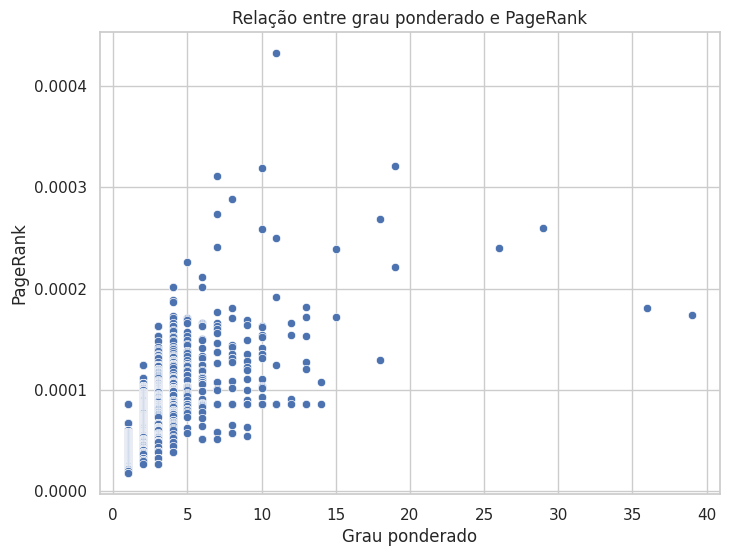

,weighted_degree,pagerank
weighted_degree,1.000000,0.462624
pagerank,0.462624,1.000000


In [65]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=item_metrics,
    x='weighted_degree',
    y='pagerank'
)

plt.title('Relação entre grau ponderado e PageRank')
plt.xlabel('Grau ponderado')
plt.ylabel('PageRank')

plt.show()

# Calculando a correlação
correlation = item_metrics[
    ['weighted_degree', 'pagerank']
].corr()

display(correlation)

### Visualizando um subgrafo

In [77]:
# Verificando quantos visitantes cada produto possui
display(
    products_per_visitor
    .value_counts()
    .sort_index()
    .rename_axis('quantidade_produtos')
    .to_frame('quantidade_visitantes')
)

,quantidade_visitantes
quantidade_produtos,
1,3932
2,605
3,222
4,91
5,43
6,40
7,20
8,9
9,7


Visitante selecionado: visitor_954684
Quantidade de produtos: 49
Produtos associados:
item_6
item_997
item_13837
item_26514
item_34269
item_47353
item_47889
item_56944
item_62252
item_74885
item_79057
item_99298
item_104858
item_156152
item_160302
item_181469
item_184206
item_195360
item_233925
item_242380
item_256271
item_264392
item_266999
item_267670
item_272144
item_274699
item_287572
item_295168
item_318106
item_320785
item_323536
item_336552
item_345755
item_350647
item_360358
item_363828
item_364230
item_365447
item_383715
item_393252
item_397335
item_411580
item_415023
item_424932
item_426026
item_432868
item_440450
item_444119
item_453546
Nós no subgrafo: 50
Arestas no subgrafo: 49


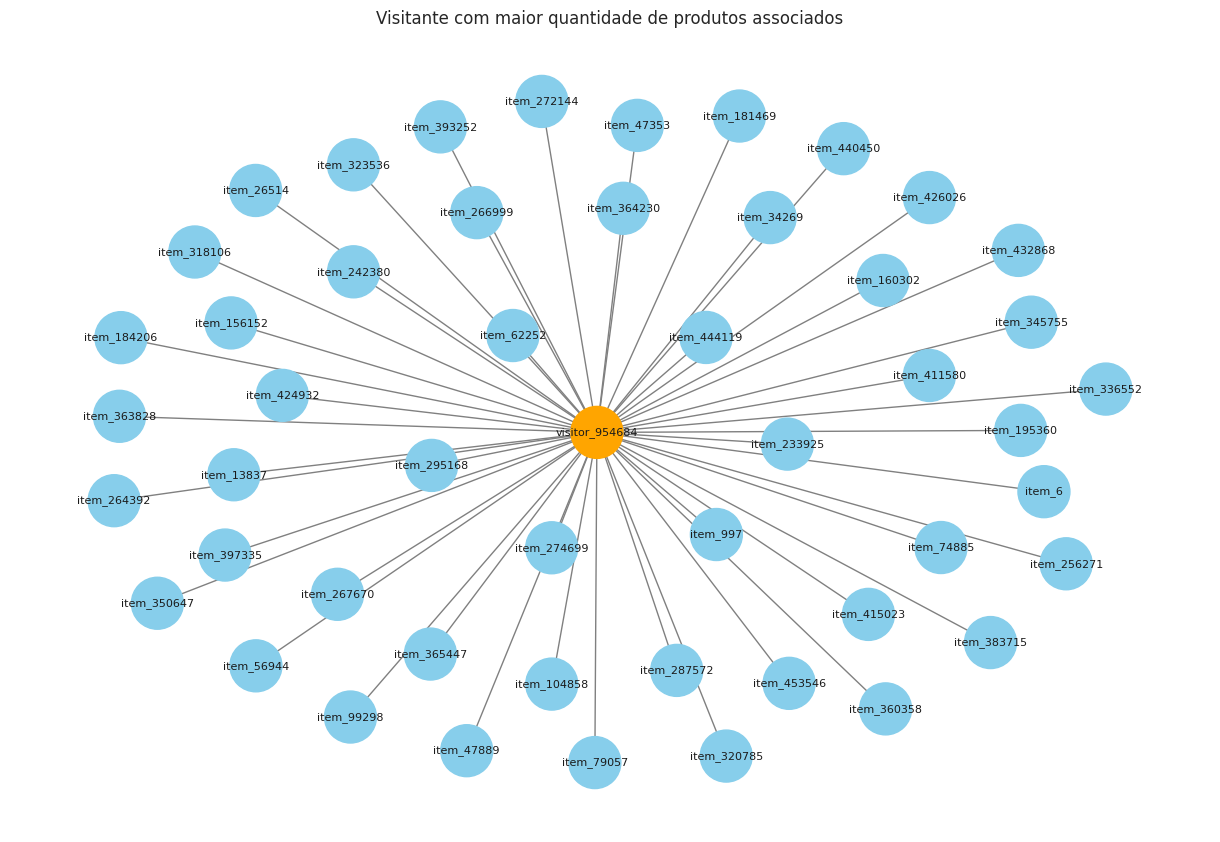

In [76]:
# Selecionando aquele que visitou mais produtos
products_per_visitor = (
    edge_data
    .groupby('visitor_node')['item_node']
    .nunique()
    .sort_values(ascending=False)
)

selected_visitor = products_per_visitor.idxmax()

print('Visitante selecionado:', selected_visitor)
print(
    'Quantidade de produtos:',
    products_per_visitor.loc[selected_visitor]
)

selected_products = list(
    G.neighbors(selected_visitor)
)

print('Produtos associados:')
for product in selected_products:
    print(product)

small_nodes = [selected_visitor] + selected_products

G_small = G.subgraph(small_nodes).copy()

print('Nós no subgrafo:', G_small.number_of_nodes())
print('Arestas no subgrafo:', G_small.number_of_edges())

plt.figure(figsize=(12, 8))

positions = nx.spring_layout(
    G_small,
    seed=42
)

node_colors = []

for node in G_small.nodes():
    if G_small.nodes[node].get('node_type') == 'visitor':
        node_colors.append('orange')
    else:
        node_colors.append('skyblue')

nx.draw(
    G_small,
    positions,
    with_labels=True,
    node_color=node_colors,
    node_size=1400,
    font_size=8,
    edge_color='gray'
)

plt.title('Visitante com maior quantidade de produtos associados')
plt.show()

In [83]:
# Limita a visualização aos primeiros produtos do visitante selecionado
products_for_visualization = selected_products[:10]

# Encontra outros visitantes conectados a esses produtos
related_visitors = set()

for product in products_for_visualization:
    related_visitors.update(
        neighbor
        for neighbor in G.neighbors(product)
        if G.nodes[neighbor].get('node_type') == 'visitor'
    )

# Limita a quantidade de visitantes para evitar um gráfico muito grande
related_visitors = list(related_visitors)[:10]

# Cria os nós do subgrafo expandido
expanded_nodes = (
    [selected_visitor]
    + related_visitors
    + products_for_visualization
)

G_expanded = G.subgraph(expanded_nodes).copy()

print('Visitantes no subgrafo:', len(related_visitors) + 1)
print('Produtos no subgrafo:', len(products_for_visualization))
print('Arestas:', G_expanded.number_of_edges())

Visitantes no subgrafo: 3
Produtos no subgrafo: 10
Arestas: 11


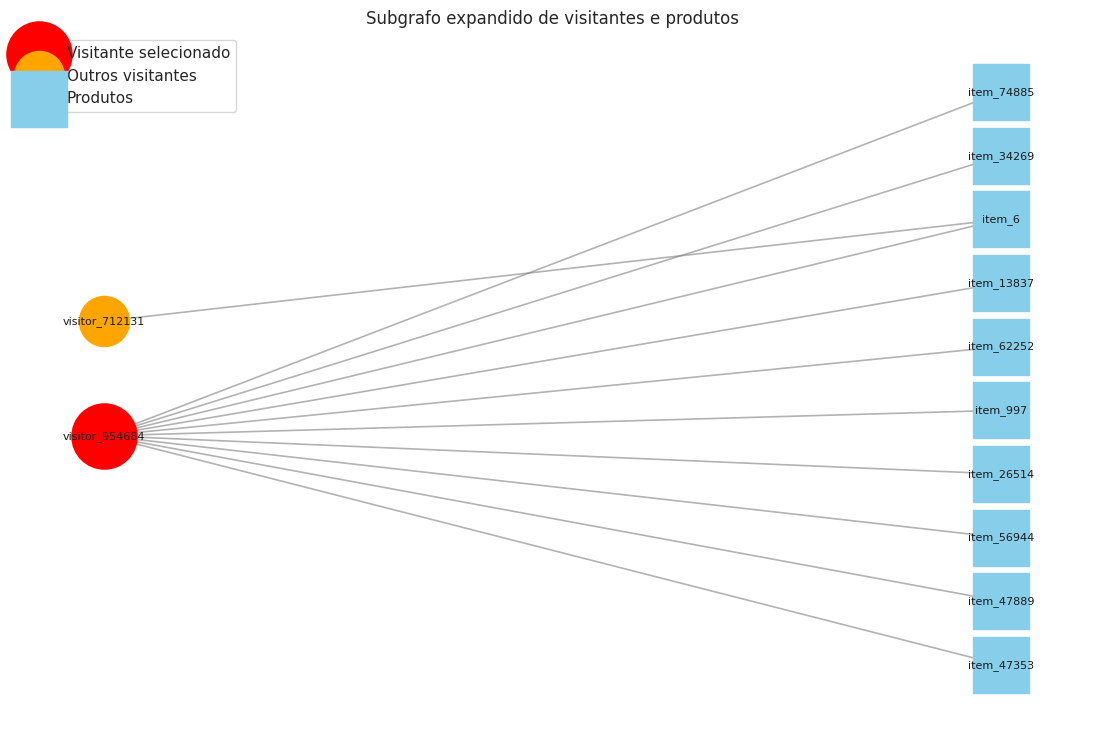

In [84]:
# Desenha o grafo
plt.figure(figsize=(14, 9))

visitor_nodes_expanded = [
    node for node in G_expanded.nodes()
    if G_expanded.nodes[node].get('node_type') == 'visitor'
]

product_nodes_expanded = [
    node for node in G_expanded.nodes()
    if G_expanded.nodes[node].get('node_type') == 'item'
]

# Cria posições manuais
positions_expanded = {}

visitor_y = np.linspace(
    -len(visitor_nodes_expanded),
    len(visitor_nodes_expanded),
    len(visitor_nodes_expanded)
)

product_y = np.linspace(
    -len(product_nodes_expanded),
    len(product_nodes_expanded),
    len(product_nodes_expanded)
)

for node, y in zip(visitor_nodes_expanded, visitor_y):
    positions_expanded[node] = (0, y)

for node, y in zip(product_nodes_expanded, product_y):
    positions_expanded[node] = (1, y)

# Desenha arestas
nx.draw_networkx_edges(
    G_expanded,
    positions_expanded,
    edge_color='gray',
    alpha=0.6,
    width=1.2
)

# Destaca o visitante escolhido
nx.draw_networkx_nodes(
    G_expanded,
    positions_expanded,
    nodelist=[selected_visitor],
    node_color='red',
    node_size=2200,
    node_shape='o',
    label='Visitante selecionado'
)

# Outros visitantes
other_visitors = [
    node for node in visitor_nodes_expanded
    if node != selected_visitor
]

nx.draw_networkx_nodes(
    G_expanded,
    positions_expanded,
    nodelist=other_visitors,
    node_color='orange',
    node_size=1300,
    node_shape='o',
    label='Outros visitantes'
)

# Produtos
nx.draw_networkx_nodes(
    G_expanded,
    positions_expanded,
    nodelist=product_nodes_expanded,
    node_color='skyblue',
    node_size=1600,
    node_shape='s',
    label='Produtos'
)

# Rótulos
nx.draw_networkx_labels(
    G_expanded,
    positions_expanded,
    font_size=8
)

plt.title(
    'Subgrafo expandido de visitantes e produtos'
)

plt.legend()
plt.axis('off')
plt.show()

### Salvando as métricas do grafo

In [78]:
item_metrics.to_csv(
    '/content/item_graph_metrics.csv',
    index=False
)

edge_data.to_csv(
    '/content/graph_edges.csv',
    index=False
)

print('Métricas e arestas salvas no ambiente do Colab.')

Métricas e arestas salvas no ambiente do Colab.


## Etapa 3: Construindo a baseline de recomendação

O baseline recomenda produtos com base na coocorrência no histórico dos visitantes.

Dois produtos são relacionados quando foram associados ao mesmo visitante.

Por exemplo:

*   Visitante A interagiu com Produto 1 e Produto 2
*   Visitante B interagiu com Produto 1 e Produto 3

Então, podem ser estabelecidas as relações:

*   Produto 1 ── Produto 2
*   Produto 1 ── Produto 3

Se um novo visitante interagiu com o Produto 1, o baseline pode recomendar:

*   Produto 2
*   Produto 3

In [85]:
# Imports
from itertools import combinations

print('Biblioteca carregada.')

Biblioteca carregada.


### Construindo o grafo produto-produto

In [86]:
item_graph = nx.Graph()

# Percorre todos os visitantes do grafo original
for visitor in visitor_nodes:
    visitor_products = list(G.neighbors(visitor))

    # Visitantes com apenas um produto não criam relação entre produtos
    if len(visitor_products) < 2:
        continue

    # Cria pares de produtos associados ao mesmo visitante
    for item_a, item_b in combinations(
        sorted(visitor_products),
        2
    ):
        # Peso da nova relação
        shared_weight = 1.0

        if item_graph.has_edge(item_a, item_b):
            item_graph[item_a][item_b]['weight'] += shared_weight
        else:
            item_graph.add_edge(
                item_a,
                item_b,
                weight=shared_weight
            )

print('Grafo produto-produto criado.')
print('Produtos:', item_graph.number_of_nodes())
print('Relações:', item_graph.number_of_edges())

Grafo produto-produto criado.
Produtos: 3219
Relações: 8335


### Visualizando as relações mais fortes

In [87]:
item_edges = pd.DataFrame(
    [
        {
            'item_a': source,
            'item_b': target,
            'weight': attributes['weight']
        }
        for source, target, attributes
        in item_graph.edges(data=True)
    ]
)

item_edges = item_edges.sort_values(
    'weight',
    ascending=False
)

display(item_edges.head(20))

,item_a,item_b,weight
3259,item_234255,item_355994,3.0
3266,item_234255,item_460188,3.0
823,item_218794,item_461686,3.0
386,item_241555,item_325310,2.0
814,item_171878,item_218794,2.0
7584,item_302311,item_357474,2.0
1604,item_437927,item_76295,2.0
1723,item_195360,item_430317,2.0
5256,item_91105,item_274798,2.0
5258,item_91105,item_302311,2.0


### Criando a função de recomendação

In [88]:
def recommend_baseline(
    visitor_node,
    graph,
    item_graph,
    top_k=10
):
    """
    Recomenda produtos para um visitante usando
    relações de coocorrência entre produtos.
    """

    # Produtos já conhecidos pelo visitante
    history = set(graph.neighbors(visitor_node))

    candidate_scores = {}

    # Percorre os produtos do histórico
    for history_item in history:

        # Se o produto não estiver no grafo produto-produto,
        # não há relações para explorar
        if history_item not in item_graph:
            continue

        # Produtos relacionados ao item do histórico
        for candidate in item_graph.neighbors(history_item):

            # Não recomenda produtos que o visitante já conhece
            if candidate in history:
                continue

            relation_weight = item_graph[
                history_item
            ][candidate]['weight']

            candidate_scores[candidate] = (
                candidate_scores.get(candidate, 0)
                + relation_weight
            )

    if not candidate_scores:
        return pd.DataFrame(
            columns=[
                'item_node',
                'recommendation_score'
            ]
        )

    recommendations = (
        pd.DataFrame(
            [
                {
                    'item_node': item,
                    'recommendation_score': score
                }
                for item, score
                in candidate_scores.items()
            ]
        )
        .sort_values(
            'recommendation_score',
            ascending=False
        )
        .head(top_k)
        .reset_index(drop=True)
    )

    return recommendations

### Testando com o visitante selecionado

In [89]:
baseline_recommendations = recommend_baseline(
    visitor_node=selected_visitor,
    graph=G,
    item_graph=item_graph,
    top_k=10
)

display(baseline_recommendations)

# Usando um visitante com pelo menos 3 produtos
eligible_visitors = products_per_visitor[
    products_per_visitor >= 3
]

selected_visitor = eligible_visitors.index[0]

baseline_recommendations = recommend_baseline(
    visitor_node=selected_visitor,
    graph=G,
    item_graph=item_graph,
    top_k=10
)

print('Visitante:', selected_visitor)
display(baseline_recommendations)

,item_node,recommendation_score
0,item_430317,2.0
1,item_272152,1.0
2,item_344010,1.0
3,item_299751,1.0
4,item_385475,1.0
5,item_390036,1.0
6,item_178147,1.0
7,item_404056,1.0
8,item_224060,1.0
9,item_258012,1.0


Visitante: visitor_954684


,item_node,recommendation_score
0,item_430317,2.0
1,item_272152,1.0
2,item_344010,1.0
3,item_299751,1.0
4,item_385475,1.0
5,item_390036,1.0
6,item_178147,1.0
7,item_404056,1.0
8,item_224060,1.0
9,item_258012,1.0


### Mostrando os produtos do histórico

In [90]:
visitor_history = list(
    G.neighbors(selected_visitor)
)

print('Produtos já conhecidos pelo visitante:')

for item in visitor_history:
    print(item)

# Comparando as recomendações
print('Produtos recomendados pelo baseline:')

for item in baseline_recommendations['item_node']:
    print(item)

Produtos já conhecidos pelo visitante:
item_6
item_997
item_13837
item_26514
item_34269
item_47353
item_47889
item_56944
item_62252
item_74885
item_79057
item_99298
item_104858
item_156152
item_160302
item_181469
item_184206
item_195360
item_233925
item_242380
item_256271
item_264392
item_266999
item_267670
item_272144
item_274699
item_287572
item_295168
item_318106
item_320785
item_323536
item_336552
item_345755
item_350647
item_360358
item_363828
item_364230
item_365447
item_383715
item_393252
item_397335
item_411580
item_415023
item_424932
item_426026
item_432868
item_440450
item_444119
item_453546
Produtos recomendados pelo baseline:
item_430317
item_272152
item_344010
item_299751
item_385475
item_390036
item_178147
item_404056
item_224060
item_258012


### Adicionando as métricas do grafo

In [91]:
# Convertendo os IDs para números
baseline_recommendations['itemid'] = (
    baseline_recommendations['item_node']
    .str.replace('item_', '', regex=False)
    .astype(int)
)

display(baseline_recommendations)

# Acrescentando o PageRank e o grau ponderado aos produtos recomendados
baseline_recommendations['pagerank'] = (
    baseline_recommendations['item_node']
    .map(pagerank_scores)
    .fillna(0)
)

baseline_recommendations['weighted_degree'] = (
    baseline_recommendations['item_node']
    .map(item_degree)
    .fillna(0)
)

display(baseline_recommendations)

,item_node,recommendation_score,itemid
0,item_430317,2.0,430317
1,item_272152,1.0,272152
2,item_344010,1.0,344010
3,item_299751,1.0,299751
4,item_385475,1.0,385475
5,item_390036,1.0,390036
6,item_178147,1.0,178147
7,item_404056,1.0,404056
8,item_224060,1.0,224060
9,item_258012,1.0,258012


,item_node,recommendation_score,itemid,pagerank,weighted_degree
0,item_430317,2.0,430317,0.000069,2.0
1,item_272152,1.0,272152,0.000052,1.0
2,item_344010,1.0,344010,0.000123,5.0
3,item_299751,1.0,299751,0.000041,1.0
4,item_385475,1.0,385475,0.000069,2.0
5,item_390036,1.0,390036,0.000081,2.0
6,item_178147,1.0,178147,0.000041,1.0
7,item_404056,1.0,404056,0.000081,2.0
8,item_224060,1.0,224060,0.000041,1.0
9,item_258012,1.0,258012,0.000094,3.0


### Visualizando o ranking do baseline

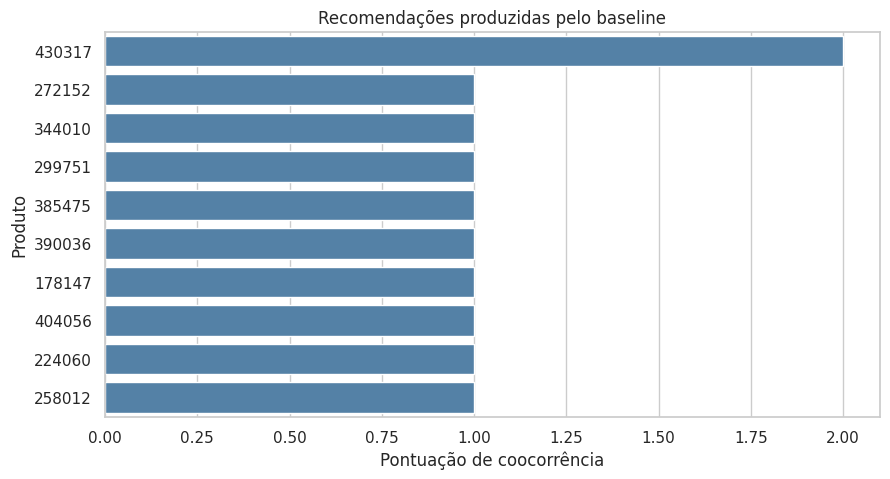

In [92]:
plt.figure(figsize=(10, 5))

plot_data = baseline_recommendations.copy()

plot_data['label'] = (
    plot_data['item_node']
    .str.replace('item_', '', regex=False)
)

sns.barplot(
    data=plot_data,
    x='recommendation_score',
    y='label',
    color='steelblue'
)

plt.title('Recomendações produzidas pelo baseline')
plt.xlabel('Pontuação de coocorrência')
plt.ylabel('Produto')

plt.show()

O baseline:

*   olha o histórico do visitante;
*   encontra produtos relacionados;
*   conta quantas vezes cada candidato aparece nas relações do grafo;
*   ordena por essa contagem.


### Etapa 4: Preparando a matriz de decisão TOPSIS

Nesta etapa serão calculados os critérios dos produtos recomendados
pelo baseline.

Os critérios utilizados inicialmente serão:

*   força da relação entre produtos;
*   PageRank;
*   grau ponderado;
*   taxa de conversão;
*   recência das interações.

#### Critérios TOPSIS
| Critério                     | Origem          | Tipo      |
| ---------------------------- | --------------- | --------- |
| Pontuação de coocorrência    | Baseline        | Benefício |
| PageRank                     | Grafo           | Benefício |
| Grau ponderado               | Grafo           | Benefício |
| Recência                     | Eventos         | Benefício |
| Taxa de conversão            | Eventos         | Benefício |

In [93]:
# Copiando os candidatos do baseline
topsis_candidates = baseline_recommendations.copy()

display(topsis_candidates)

# Verificando as colunas
print(topsis_candidates.columns.tolist())

,item_node,recommendation_score,itemid,pagerank,weighted_degree
0,item_430317,2.0,430317,0.000069,2.0
1,item_272152,1.0,272152,0.000052,1.0
2,item_344010,1.0,344010,0.000123,5.0
3,item_299751,1.0,299751,0.000041,1.0
4,item_385475,1.0,385475,0.000069,2.0
5,item_390036,1.0,390036,0.000081,2.0
6,item_178147,1.0,178147,0.000041,1.0
7,item_404056,1.0,404056,0.000081,2.0
8,item_224060,1.0,224060,0.000041,1.0
9,item_258012,1.0,258012,0.000094,3.0


['item_node', 'recommendation_score', 'itemid', 'pagerank', 'weighted_degree']


### Calculando as estatísticas para cada produto

In [94]:
item_behavior = events.copy()

item_behavior['item_node'] = (
    'item_' + item_behavior['itemid'].astype(str)
)

item_behavior.head()

,timestamp,visitorid,event,itemid,transactionid,datetime,item_node
0,1433193132535,1134473,view,396045,NaN,2015-06-01 21:12:12.535,item_396045
1,1433194696771,1314862,view,344224,NaN,2015-06-01 21:38:16.771,item_344224
2,1433220848630,467124,view,396318,NaN,2015-06-02 04:54:08.630,item_396318
3,1433218109710,1121229,view,370889,NaN,2015-06-02 04:08:29.710,item_370889
4,1433178802896,39027,view,26210,NaN,2015-06-01 17:13:22.896,item_26210


### Calculando visualizações, carrinhos e transações

In [95]:
views_by_item = (
    item_behavior[item_behavior['event'] == 'view']
    .groupby('item_node')
    .size()
    .rename('views')
)

carts_by_item = (
    item_behavior[item_behavior['event'] == 'addtocart']
    .groupby('item_node')
    .size()
    .rename('addtocart')
)

transactions_by_item = (
    item_behavior[item_behavior['event'] == 'transaction']
    .groupby('item_node')
    .size()
    .rename('transactions')
)

item_behavior_stats = pd.concat(
    [
        views_by_item,
        carts_by_item,
        transactions_by_item
    ],
    axis=1
).fillna(0)

display(item_behavior_stats.head())

,views,addtocart,transactions
item_node,,,
item_100004,1.0,0.0,0.0
item_100049,1.0,0.0,0.0
item_100150,2.0,0.0,0.0
item_100172,1.0,0.0,0.0
item_100296,3.0,0.0,0.0


### Calculando a taxa de conversão

In [96]:
item_behavior_stats['conversion_rate'] = (
    item_behavior_stats['transactions'] /
    item_behavior_stats['views'].clip(lower=1)
)

display(
    item_behavior_stats
    .sort_values('conversion_rate', ascending=False)
    .head(10)
)

,views,addtocart,transactions,conversion_rate
item_node,,,,
item_365758,0.0,1.0,1.0,1.0
item_361982,1.0,1.0,1.0,1.0
item_122604,1.0,1.0,1.0,1.0
item_257115,1.0,1.0,1.0,1.0
item_415562,1.0,1.0,1.0,1.0
item_144599,0.0,1.0,1.0,1.0
item_225572,0.0,1.0,1.0,1.0
item_250375,0.0,1.0,1.0,1.0
item_85377,1.0,1.0,1.0,1.0


### Calculando a recência

In [97]:
last_interaction = (
    item_behavior
    .groupby('item_node')['datetime']
    .max()
    .rename('last_interaction')
)

item_behavior_stats = item_behavior_stats.join(
    last_interaction
)

reference_date = item_behavior['datetime'].max()

item_behavior_stats['days_since_last_interaction'] = (
    reference_date -
    item_behavior_stats['last_interaction']
).dt.total_seconds() / (24 * 60 * 60)

In [98]:
# Transformando a distância em uma pontuação de recência
item_behavior_stats['recency_score'] = (
    1 /
    (1 + item_behavior_stats['days_since_last_interaction'])
)

display(
    item_behavior_stats[
        [
            'last_interaction',
            'days_since_last_interaction',
            'recency_score'
        ]
    ].head()
)

,last_interaction,days_since_last_interaction,recency_score
item_node,,,
item_100004,2015-05-08 00:18:46.255,133.040359,0.007460
item_100049,2015-08-06 04:21:59.655,42.871454,0.022794
item_100150,2015-06-20 21:04:29.083,89.175280,0.011090
item_100172,2015-07-02 11:52:57.055,77.558290,0.012729
item_100296,2015-07-17 01:29:56.413,62.990936,0.015627


### Juntando os critérios

In [99]:
topsis_matrix = topsis_candidates[
    [
        'item_node',
        'recommendation_score',
        'pagerank',
        'weighted_degree'
    ]
].copy()

topsis_matrix = topsis_matrix.merge(
    item_behavior_stats[
        [
            'conversion_rate',
            'recency_score'
        ]
    ],
    left_on='item_node',
    right_index=True,
    how='left'
)

topsis_matrix = topsis_matrix.fillna(0)

display(topsis_matrix)

,item_node,recommendation_score,pagerank,weighted_degree,conversion_rate,recency_score
0,item_430317,2.0,0.000069,2.0,0.0,0.015806
1,item_272152,1.0,0.000052,1.0,0.0,0.010710
2,item_344010,1.0,0.000123,5.0,0.0,0.185140
3,item_299751,1.0,0.000041,1.0,0.0,0.025035
4,item_385475,1.0,0.000069,2.0,0.0,0.025038
5,item_390036,1.0,0.000081,2.0,0.0,0.239037
6,item_178147,1.0,0.000041,1.0,0.0,0.010060
7,item_404056,1.0,0.000081,2.0,0.0,0.043132
8,item_224060,1.0,0.000041,1.0,0.0,0.010060
9,item_258012,1.0,0.000094,3.0,0.0,0.016901


### Verificando a matriz de decisão

In [100]:
criteria = [
    'recommendation_score',
    'pagerank',
    'weighted_degree',
    'conversion_rate',
    'recency_score'
]

decision_matrix = topsis_matrix[criteria].astype(float)

display(decision_matrix)

,recommendation_score,pagerank,weighted_degree,conversion_rate,recency_score
0,2.0,0.000069,2.0,0.0,0.015806
1,1.0,0.000052,1.0,0.0,0.010710
2,1.0,0.000123,5.0,0.0,0.185140
3,1.0,0.000041,1.0,0.0,0.025035
4,1.0,0.000069,2.0,0.0,0.025038
5,1.0,0.000081,2.0,0.0,0.239037
6,1.0,0.000041,1.0,0.0,0.010060
7,1.0,0.000081,2.0,0.0,0.043132
8,1.0,0.000041,1.0,0.0,0.010060
9,1.0,0.000094,3.0,0.0,0.016901


### Definindo os pesos

In [101]:
weights = {
    'recommendation_score': 0.20,
    'pagerank': 0.20,
    'weighted_degree': 0.20,
    'conversion_rate': 0.20,
    'recency_score': 0.20
}

print('Soma dos pesos:', sum(weights.values()))

Soma dos pesos: 1.0


### Normalizando a matriz

In [102]:
matrix_values = decision_matrix.to_numpy()

denominators = np.sqrt(
    (matrix_values ** 2).sum(axis=0)
)

# Evita divisão por zero
denominators[denominators == 0] = 1

normalized_matrix = (
    matrix_values / denominators
)

normalized_df = pd.DataFrame(
    normalized_matrix,
    columns=criteria,
    index=topsis_matrix['item_node']
)

display(normalized_df)

,recommendation_score,pagerank,weighted_degree,conversion_rate,recency_score
item_node,,,,,
item_430317,0.55470,0.296838,0.272166,0.0,0.051178
item_272152,0.27735,0.224668,0.136083,0.0,0.034679
item_344010,0.27735,0.527968,0.680414,0.0,0.599470
item_299751,0.27735,0.175108,0.136083,0.0,0.081061
item_385475,0.27735,0.293835,0.272166,0.0,0.081071
item_390036,0.27735,0.348134,0.272166,0.0,0.773983
item_178147,0.27735,0.176725,0.136083,0.0,0.032574
item_404056,0.27735,0.348134,0.272166,0.0,0.139658
item_224060,0.27735,0.176725,0.136083,0.0,0.032574


### Aplicando os pesos

In [103]:
weighted_matrix = normalized_df.copy()

for criterion in criteria:
    weighted_matrix[criterion] = (
        weighted_matrix[criterion] *
        weights[criterion]
    )

display(weighted_matrix)

,recommendation_score,pagerank,weighted_degree,conversion_rate,recency_score
item_node,,,,,
item_430317,0.11094,0.059368,0.054433,0.0,0.010236
item_272152,0.05547,0.044934,0.027217,0.0,0.006936
item_344010,0.05547,0.105594,0.136083,0.0,0.119894
item_299751,0.05547,0.035022,0.027217,0.0,0.016212
item_385475,0.05547,0.058767,0.054433,0.0,0.016214
item_390036,0.05547,0.069627,0.054433,0.0,0.154797
item_178147,0.05547,0.035345,0.027217,0.0,0.006515
item_404056,0.05547,0.069627,0.054433,0.0,0.027932
item_224060,0.05547,0.035345,0.027217,0.0,0.006515


### Calculando as soluções ideais

In [104]:
positive_ideal = weighted_matrix.max(axis=0)
negative_ideal = weighted_matrix.min(axis=0)

print('Solução ideal positiva:')
display(positive_ideal.to_frame('valor'))

print('Solução ideal negativa:')
display(negative_ideal.to_frame('valor'))

Solução ideal positiva:


,valor
recommendation_score,0.110940
pagerank,0.105594
weighted_degree,0.136083
conversion_rate,0.000000
recency_score,0.154797


Solução ideal negativa:


,valor
recommendation_score,0.055470
pagerank,0.035022
weighted_degree,0.027217
conversion_rate,0.000000
recency_score,0.006515


### Calculando as distâncias

In [105]:
distance_positive = np.sqrt(
    (
        (weighted_matrix - positive_ideal) ** 2
    ).sum(axis=1)
)

distance_negative = np.sqrt(
    (
        (weighted_matrix - negative_ideal) ** 2
    ).sum(axis=1)
)

### Calculando o coeficiente TOPSIS

In [106]:
topsis_score = (
    distance_negative /
    (distance_positive + distance_negative + 1e-12)
)

topsis_results = topsis_matrix.copy()

topsis_results['distance_positive'] = distance_positive.values
topsis_results['distance_negative'] = distance_negative.values
topsis_results['topsis_score'] = topsis_score.values

topsis_results = topsis_results.sort_values(
    'topsis_score',
    ascending=False
).reset_index(drop=True)

topsis_results['topsis_rank'] = (
    topsis_results.index + 1
)

display(topsis_results)

,item_node,recommendation_score,pagerank,weighted_degree,conversion_rate,recency_score,distance_positive,distance_negative,topsis_score,topsis_rank
0,item_344010,1.0,0.000123,5.0,0.0,0.185140,0.065537,0.172299,0.724444,1
1,item_390036,1.0,0.000081,2.0,0.0,0.239037,0.105058,0.154680,0.595522,2
2,item_258012,1.0,0.000094,3.0,0.0,0.016901,0.165463,0.070878,0.299897,3
3,item_430317,2.0,0.000069,2.0,0.0,0.015806,0.172341,0.066515,0.278473,4
4,item_404056,1.0,0.000081,2.0,0.0,0.043132,0.164718,0.048958,0.229125,5
5,item_385475,1.0,0.000069,2.0,0.0,0.025038,0.176469,0.037399,0.174868,6
6,item_272152,1.0,0.000052,1.0,0.0,0.010710,0.201175,0.009921,0.046997,7
7,item_299751,1.0,0.000041,1.0,0.0,0.025035,0.197775,0.009697,0.046741,8
8,item_178147,1.0,0.000041,1.0,0.0,0.010060,0.204575,0.000323,0.001578,9
9,item_224060,1.0,0.000041,1.0,0.0,0.010060,0.204576,0.000323,0.001578,10


### Baseline x TOPSIS

In [107]:
comparison = topsis_results[
    [
        'item_node',
        'recommendation_score',
        'pagerank',
        'weighted_degree',
        'conversion_rate',
        'recency_score',
        'topsis_score',
        'topsis_rank'
    ]
].copy()

comparison['baseline_rank'] = (
    comparison['recommendation_score']
    .rank(
        method='first',
        ascending=False
    )
    .astype(int)
)

comparison = comparison.sort_values(
    'topsis_rank'
)

display(comparison)

,item_node,recommendation_score,pagerank,weighted_degree,conversion_rate,recency_score,topsis_score,topsis_rank,baseline_rank
0,item_344010,1.0,0.000123,5.0,0.0,0.185140,0.724444,1,2
1,item_390036,1.0,0.000081,2.0,0.0,0.239037,0.595522,2,3
2,item_258012,1.0,0.000094,3.0,0.0,0.016901,0.299897,3,4
3,item_430317,2.0,0.000069,2.0,0.0,0.015806,0.278473,4,1
4,item_404056,1.0,0.000081,2.0,0.0,0.043132,0.229125,5,5
5,item_385475,1.0,0.000069,2.0,0.0,0.025038,0.174868,6,6
6,item_272152,1.0,0.000052,1.0,0.0,0.010710,0.046997,7,7
7,item_299751,1.0,0.000041,1.0,0.0,0.025035,0.046741,8,8
8,item_178147,1.0,0.000041,1.0,0.0,0.010060,0.001578,9,9
9,item_224060,1.0,0.000041,1.0,0.0,0.010060,0.001578,10,10


### Visualizando a mudança no ranking

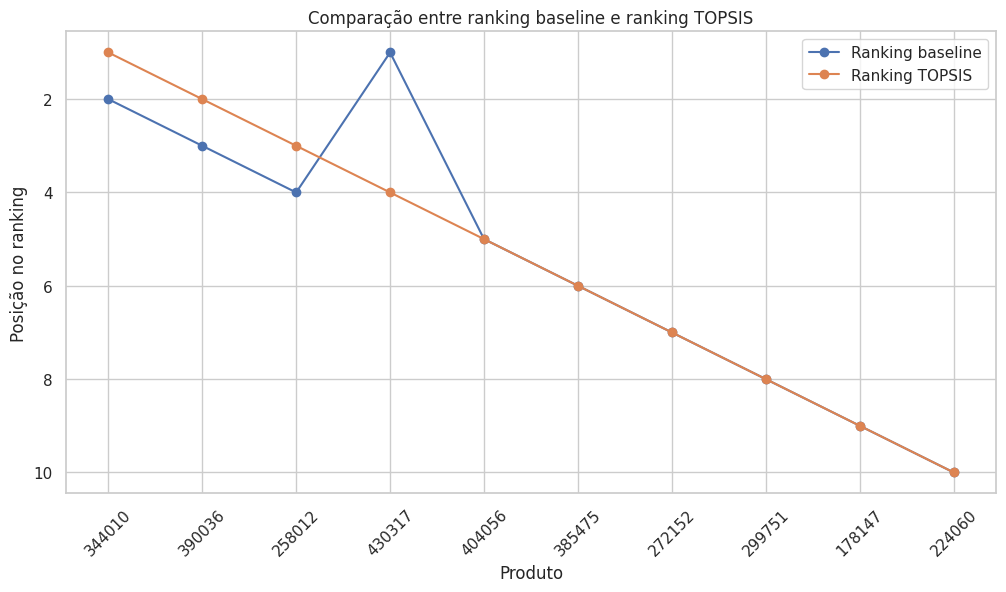

In [108]:
plot_comparison = comparison.copy()

plot_comparison['item_label'] = (
    plot_comparison['item_node']
    .str.replace('item_', '', regex=False)
)

plot_comparison = plot_comparison.sort_values(
    'topsis_rank',
    ascending=True
)

plt.figure(figsize=(12, 6))

x = np.arange(len(plot_comparison))

plt.plot(
    x,
    plot_comparison['baseline_rank'],
    marker='o',
    label='Ranking baseline'
)

plt.plot(
    x,
    plot_comparison['topsis_rank'],
    marker='o',
    label='Ranking TOPSIS'
)

plt.xticks(
    x,
    plot_comparison['item_label'],
    rotation=45
)

plt.gca().invert_yaxis()

plt.title('Comparação entre ranking baseline e ranking TOPSIS')
plt.xlabel('Produto')
plt.ylabel('Posição no ranking')
plt.legend()

plt.show()

### Salvando os resultados

In [109]:
topsis_results.to_csv(
    '/content/topsis_results.csv',
    index=False
)

comparison.to_csv(
    '/content/baseline_vs_topsis.csv',
    index=False
)

print('Resultados do TOPSIS salvos.')

Resultados do TOPSIS salvos.
